# Step 7: Compliance, Accountability and Human Oversight (simulated)

This module is a **simulation in Phase 1**. Folktables has no policy rules, review records or decision logs, so only part of survey section 4.5 can be measured:

| Measure | Phase 1 |
|---|---|
| Human Review Rate | simulated: decisions with confidence below a threshold go to a person |
| High-Risk Escalation Rate | simulated: share of the model's **errors** that reach a person |
| Residual error rate | share of all decisions that are wrong **and** not reviewed |
| Compliance Rate | **not assessed**: needs policy rules |
| Audit Traceability Rate | **not assessed**: needs a decision log |

The two not-assessed measures are computed only when real inputs are supplied (Phase 2 synthetic data) and are never guessed.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from src.model import load_processed, build_dtypes, apply_dtypes

PROCESSED_DIR = os.path.abspath("../data/processed")
RESULTS_DIR = os.path.abspath("../results")
from src.audit.oversight import audit_oversight, oversight_curve, DEFAULT_THRESHOLDS
X_train, X_test, y_train, y_test, g_train, g_test = load_processed(PROCESSED_DIR)
dtypes = build_dtypes(X_train, X_test)
Xte = apply_dtypes(X_test, dtypes)
yte = y_test.to_numpy()

model = XGBClassifier()
model.load_model(os.path.join(RESULTS_DIR, "baseline_xgb.json"))
p = model.predict_proba(Xte)[:, 1]
print("Test rows:", Xte.shape)


Test rows: (38642, 10)


In [2]:
result = audit_oversight(yte, p, review_threshold=0.70)
print(result.summary())

Human oversight: risk 0.482 (pass)
  - SIMULATED policy: decisions with confidence below 70% go to a human. That reviews 21.3% of decisions and catches 47.8% of the model's errors; 9.6% of all decisions are wrong and unreviewed.
  - Not assessed in Phase 1: compliance rate (no policy rules supplied); audit traceability rate (no decision log supplied).


## The trade-off

A higher review threshold catches more errors but sends more cases to a person. This table is what the dashboard's slider moves along.

In [3]:
curve = result.details["curve"]
curve.round(3)

,review_threshold,review_rate,errors_caught,residual_error_rate
0,0.50,0.000,0.000,0.184
1,0.55,0.050,0.127,0.161
2,0.60,0.101,0.249,0.139
3,0.65,0.155,0.363,0.117
4,0.70,0.213,0.478,0.096
5,0.75,0.274,0.573,0.079
6,0.80,0.343,0.665,0.062
7,0.85,0.426,0.757,0.045
8,0.90,0.528,0.851,0.027
9,0.95,0.679,0.935,0.012


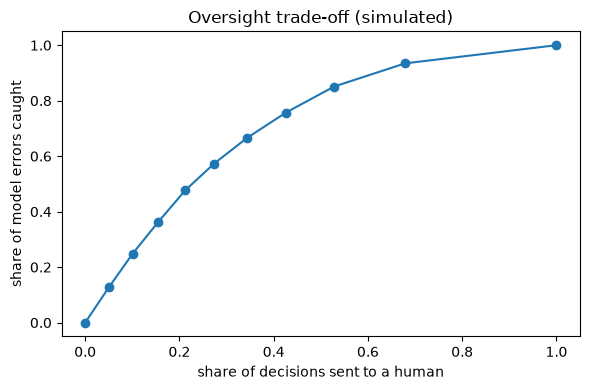

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(curve["review_rate"], curve["errors_caught"], "o-")
ax.set_xlabel("share of decisions sent to a human")
ax.set_ylabel("share of model errors caught")
ax.set_title("Oversight trade-off (simulated)")
plt.tight_layout(); plt.show()

## Sensitivity to the review threshold

In [5]:
rows = []
for t in (0.6, 0.7, 0.8, 0.9):
    r = audit_oversight(yte, p, review_threshold=t)
    rows.append({"review_threshold": t, "review_rate": round(r.metrics["human_review_rate"], 3),
                 "errors_caught": round(r.metrics["high_risk_escalation_rate"], 3),
                 "residual_error": round(r.metrics["residual_unreviewed_error_rate"], 3),
                 "risk": round(r.risk, 3), "status": r.status})
pd.DataFrame(rows)

,review_threshold,review_rate,errors_caught,residual_error,risk,status
0,0.6,0.101,0.249,0.139,0.693,warn
1,0.7,0.213,0.478,0.096,0.482,pass
2,0.8,0.343,0.665,0.062,0.309,pass
3,0.9,0.528,0.851,0.027,0.137,pass


In [6]:
from src.audit.common import save_result
save_result(result, os.path.join(RESULTS_DIR, "oversight_result.json"))
print("Saved")

Saved


## Summary and next step

- Simulated a confidence-based review policy and measured its cost and benefit.
- Recorded that compliance and traceability are not assessed in Phase 1.

**Next:** notebook 08, the Governance Risk Score.